# Hypothesis tests: collective vs. individual framing in convention speeches

First-person pronoun framing (We vs. I) in U.S. presidential nominating
convention speeches, 2004-2024, by party (H1, H1b) and by incumbency
status (H2, H2b).

**Conventions in this notebook**
- All inferential tests are **two-sided** permutation tests (10,000 shuffles,
  seed 42), reported alongside 95% bootstrap confidence intervals. No
  hypothesis here was pre-registered, so directional one-sided tests are not
  used.
- Plots read only from computed values; no figures or numbers are hard-coded
  in prose, so results cannot silently drift.
- Two parameters at the top control the analysis: the word-count cutoff and
  how 2024 incumbency is coded. The sensitivity section re-runs the
  incumbency tests under every 2024 coding and across a range of cutoffs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WORD_CUTOFF = 215            # minimum speech length in words (see threshold note)
INCUMBENCY_2024 = "exclude"  # primary analysis. Options:
                             #   "exclude"       - drop 2024 from H2/H2b (primary)
                             #   "dem_incumbent" - 2024 Democrats coded incumbent
                             #   "rep_incumbent" - 2024 Republicans coded incumbent
SEED  = 42
N_PERM = 10_000
N_BOOT = 10_000

PARTY_COLORS = {"Democratic": "#3498db", "Republican": "#e74c3c"}

# ---------------------------------------------------------------------------
# Figure output
# ---------------------------------------------------------------------------
# Figures are written to this repo's figures/ folder and, when the private
# working repo is checked out as a sibling directory, also mirrored into its
# manuscript figures folder. Each target is written only if its PARENT
# directory already exists, so a public clone (which has no working repo
# alongside it) automatically skips the manuscript mirror.
FIGURE_DIRS = [
    os.path.abspath(os.path.join("..", "figures")),
    os.path.abspath(os.path.join("..", "..", "convention-speeches",
                                 "paper", "manuscript", "figures")),
]

def savefig(fig, name, dpi=300):
    """Save `fig` as `name` into every figure dir whose parent exists."""
    written = []
    for d in FIGURE_DIRS:
        if os.path.isdir(os.path.dirname(d)):
            os.makedirs(d, exist_ok=True)
            path = os.path.join(d, name)
            fig.savefig(path, dpi=dpi, bbox_inches="tight")
            written.append(path)
    print("saved:", name, "->", " | ".join(written) if written else "(no targets)")
    return written

In [2]:
df_all = pd.read_csv("../data/pronoun_counts.csv")
print(f"Loaded {len(df_all)} speeches (pre-filter)")

df = df_all[df_all["word_count"] >= WORD_CUTOFF].reset_index(drop=True)
print(f"After >= {WORD_CUTOFF}-word filter: {len(df)} speeches")
print(df["party"].value_counts().to_string())
print("Years:", sorted(df["year"].unique()))

Loaded 1800 speeches (pre-filter)
After >= 215-word filter: 1263 speeches
party
Democratic    786
Republican    477
Years: [2004, 2008, 2012, 2016, 2020, 2024]


## Minimum speech length

Speeches shorter than `WORD_CUTOFF` words are excluded. The default of 215 is derived from a simple geometric model of pronoun waiting time. Across the corpus, any single word is a target first-person pronoun ("I" or "we") with probability about 0.0175, so the expected wait for the first occurrence of each is about 57 words, and the expected wait until *both* have appeared is about 85 words. At 85 words, though, both pronouns are present only ~50% of the time. Requiring a 95% chance that both appear gives a minimum length of 211 words, which we round up to 215 as a conservative cutoff. The exact post-filter counts are printed above and recomputed for each cutoff in the sensitivity section.

In [3]:
def permutation_test(group1, group2, n_permutations=N_PERM,
                     alternative="two-sided", seed=SEED):
    """Permutation test for a difference in means. Two-sided by default."""
    np.random.seed(seed)
    g1 = np.asarray(group1, dtype=float)
    g2 = np.asarray(group2, dtype=float)
    observed = g1.mean() - g2.mean()
    combined = np.concatenate([g1, g2])
    n1 = len(g1)
    null = np.empty(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(combined)
        null[i] = combined[:n1].mean() - combined[n1:].mean()
    if alternative == "two-sided":
        p = np.mean(np.abs(null) >= abs(observed))
    elif alternative == "greater":
        p = np.mean(null >= observed)
    elif alternative == "less":
        p = np.mean(null <= observed)
    else:
        raise ValueError(alternative)
    return {"observed_diff": observed, "p_value": p, "null": null,
            "g1_mean": g1.mean(), "g2_mean": g2.mean(),
            "n1": len(g1), "n2": len(g2)}


def bootstrap_ci(group1, group2, n_bootstrap=N_BOOT, ci=95, seed=SEED):
    """Bootstrap CI for a difference in means."""
    np.random.seed(seed)
    g1 = np.asarray(group1, dtype=float)
    g2 = np.asarray(group2, dtype=float)
    observed = g1.mean() - g2.mean()
    boot = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        s1 = np.random.choice(g1, size=len(g1), replace=True)
        s2 = np.random.choice(g2, size=len(g2), replace=True)
        boot[i] = s1.mean() - s2.mean()
    lo = np.percentile(boot, (100 - ci) / 2)
    hi = np.percentile(boot, 100 - (100 - ci) / 2)
    return {"observed_diff": observed, "ci_lower": lo, "ci_upper": hi,
            "boot": boot, "ci_level": ci}


def summarize(label, perm, boot):
    """Print a compact, single-source-of-truth result block."""
    sig = "reject H0" if perm["p_value"] < 0.05 else "fail to reject H0"
    print(label)
    print(f"  group means:   {perm['g1_mean']:+.3f}  vs  {perm['g2_mean']:+.3f}"
          f"   (n = {perm['n1']}, {perm['n2']})")
    print(f"  observed diff: {perm['observed_diff']:+.3f}")
    print(f"  two-sided permutation p: {perm['p_value']:.4f}")
    print(f"  {boot['ci_level']}% bootstrap CI: "
          f"[{boot['ci_lower']:+.3f}, {boot['ci_upper']:+.3f}]")
    print(f"  -> {sig} at alpha = 0.05")


def plot_test(perm, boot, title, g1_label, g2_label, fname):
    """Two-panel diagnostic: permutation null + bootstrap distribution."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(perm["null"], bins=50, density=True, color="steelblue",
             alpha=0.7, edgecolor="white")
    ax1.axvline(perm["observed_diff"], color="red", lw=2, ls="--",
                label=f"observed {perm['observed_diff']:+.3f}")
    ax1.set_title(f"Permutation null  (two-sided p = {perm['p_value']:.4f})",
                  fontweight="bold")
    ax1.set_xlabel(f"mean diff ({g1_label} - {g2_label})")
    ax1.legend()
    ax2.hist(boot["boot"], bins=50, density=True, color="steelblue",
             alpha=0.7, edgecolor="white")
    ax2.axvline(boot["observed_diff"], color="red", lw=2, ls="--",
                label="observed")
    ax2.axvline(boot["ci_lower"], color="green", lw=2, ls="--",
                label=f"{boot['ci_level']}% CI "
                      f"[{boot['ci_lower']:+.2f}, {boot['ci_upper']:+.2f}]")
    ax2.axvline(boot["ci_upper"], color="green", lw=2, ls="--")
    ax2.axvline(0, color="black", lw=1, alpha=0.5)
    ax2.set_title("Bootstrap distribution", fontweight="bold")
    ax2.set_xlabel(f"mean diff ({g1_label} - {g2_label})")
    ax2.legend()
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()

## Hypothesis 1 - Party and collective framing

**H0:** Democrats and Republicans do not differ in collective framing gap (We - I).
**H1:** The two parties differ (two-sided).

Collective gap = `we_rate - i_rate`; positive values indicate more collective ("we") framing, negative values more individual ("I") framing. 2024 is included here: this is a party comparison, with no incumbency ambiguity.

In [13]:
dem_gap = df.loc[df["party"] == "Democratic", "collective_gap"]
rep_gap = df.loc[df["party"] == "Republican", "collective_gap"]

h1_perm = permutation_test(dem_gap, rep_gap)
h1_boot = bootstrap_ci(dem_gap, rep_gap)
summarize("H1: collective gap, Democratic vs Republican", h1_perm, h1_boot)

H1: collective gap, Democratic vs Republican
  group means:   +2.671  vs  -0.364   (n = 786, 477)
  observed diff: +3.035
  two-sided permutation p: 0.0052
  95% bootstrap CI: [+0.884, +5.163]
  -> reject H0 at alpha = 0.05


saved: pronoun_trends.png -> /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/figures/pronoun_trends.png | /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/paper/manuscript/figures/pronoun_trends.png


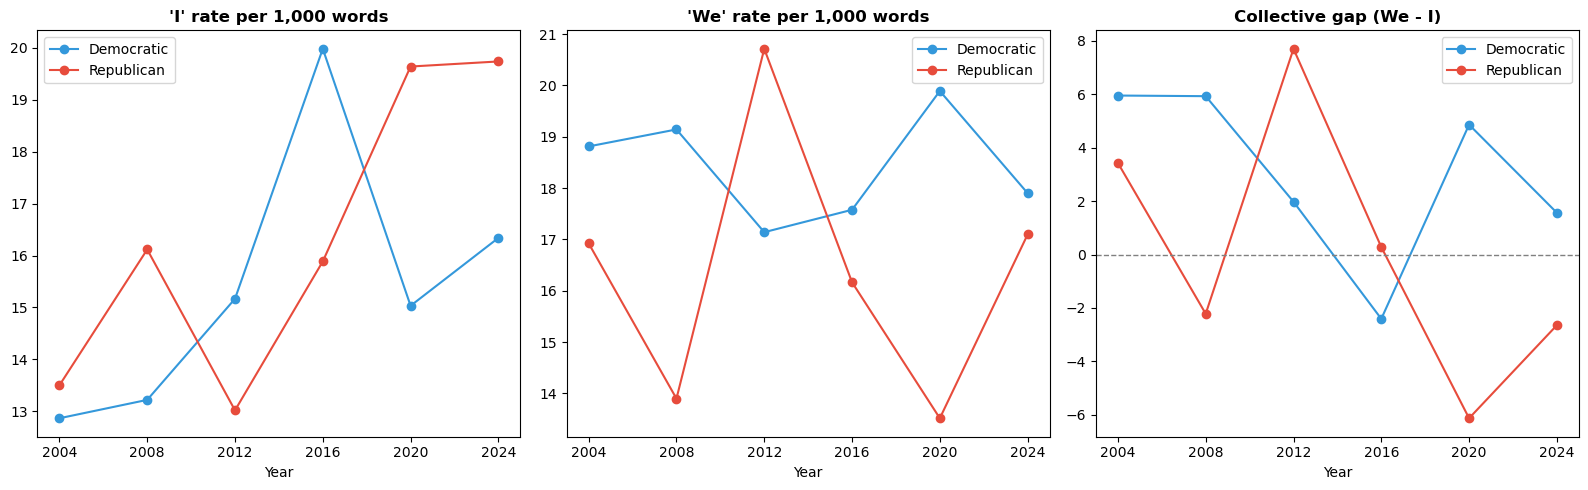

In [14]:
# Year-by-party trends (descriptive)
year_party = (df.groupby(["year", "party"])[["i_rate", "we_rate", "collective_gap"]]
                .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, title) in zip(axes, [
    ("i_rate",         "'I' rate per 1,000 words"),
    ("we_rate",        "'We' rate per 1,000 words"),
    ("collective_gap", "Collective gap (We - I)"),
]):
    for party, color in PARTY_COLORS.items():
        d = year_party[year_party["party"] == party]
        ax.plot(d["year"], d[metric], marker="o", label=party, color=color)
    if metric == "collective_gap":
        ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks(sorted(df["year"].unique()))
    ax.legend()
fig.tight_layout()
savefig(fig, "pronoun_trends.png")
plt.show()

saved: h1_party_gap.png -> /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/figures/h1_party_gap.png | /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/paper/manuscript/figures/h1_party_gap.png


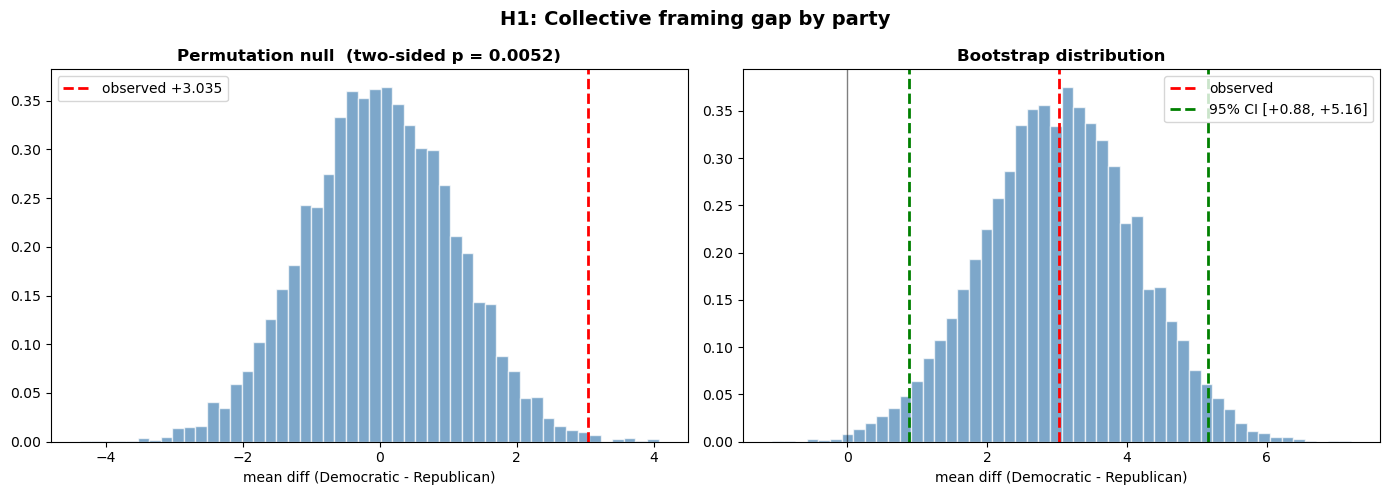

In [15]:
plot_test(h1_perm, h1_boot,
          "H1: Collective framing gap by party",
          "Democratic", "Republican", "h1_party_gap.png")

### Result - H1

Read the verdict from the printed summary and the bootstrap CI above: when the 95% CI excludes zero and the two-sided p is below 0.05, the parties differ significantly in collective framing, in the direction given by the sign of the observed difference (positive = Democrats more collective). The numbers are deliberately not restated here so the prose cannot drift from the computation.

## Hypothesis 1b - Year by year

The same two-sided test is run within each convention cycle. Results are collected into the `year_results` dict, and the forest plot below reads only from that dict, so the figure can never drift from the printed values.

In [16]:
year_results = {}
for year in sorted(df["year"].unique()):
    dy = df[df["year"] == year]
    dem = dy.loc[dy["party"] == "Democratic", "collective_gap"]
    rep = dy.loc[dy["party"] == "Republican", "collective_gap"]
    perm = permutation_test(dem, rep)
    boot = bootstrap_ci(dem, rep)
    year_results[year] = {
        "diff": perm["observed_diff"], "p_value": perm["p_value"],
        "ci_lower": boot["ci_lower"], "ci_upper": boot["ci_upper"],
        "dem_mean": perm["g1_mean"], "rep_mean": perm["g2_mean"],
        "significant": perm["p_value"] < 0.05,
    }
    flag = "SIG" if perm["p_value"] < 0.05 else "ns"
    print(f"{year} | D {perm['g1_mean']:+.2f} | R {perm['g2_mean']:+.2f} | "
          f"diff {perm['observed_diff']:+.2f} | p={perm['p_value']:.4f} | "
          f"CI [{boot['ci_lower']:+.2f}, {boot['ci_upper']:+.2f}] | {flag}")

2004 | D +5.95 | R +3.42 | diff +2.52 | p=0.3466 | CI [-2.47, +7.53] | ns
2008 | D +5.92 | R -2.22 | diff +8.14 | p=0.0025 | CI [+2.80, +13.34] | SIG
2012 | D +1.97 | R +7.70 | diff -5.72 | p=0.0330 | CI [-11.00, -0.37] | SIG
2016 | D -2.41 | R +0.28 | diff -2.69 | p=0.3204 | CI [-7.55, +2.10] | ns
2020 | D +4.86 | R -6.13 | diff +10.98 | p=0.0005 | CI [+4.91, +17.02] | SIG
2024 | D +1.56 | R -2.64 | diff +4.21 | p=0.0640 | CI [-0.29, +8.55] | ns


saved: h1b_forest.png -> /sessions/brave-epic-goodall/mnt/convention-speeches-paper/figures/h1b_forest.png | /sessions/brave-epic-goodall/mnt/convention-speeches/paper/manuscript/figures/h1b_forest.png


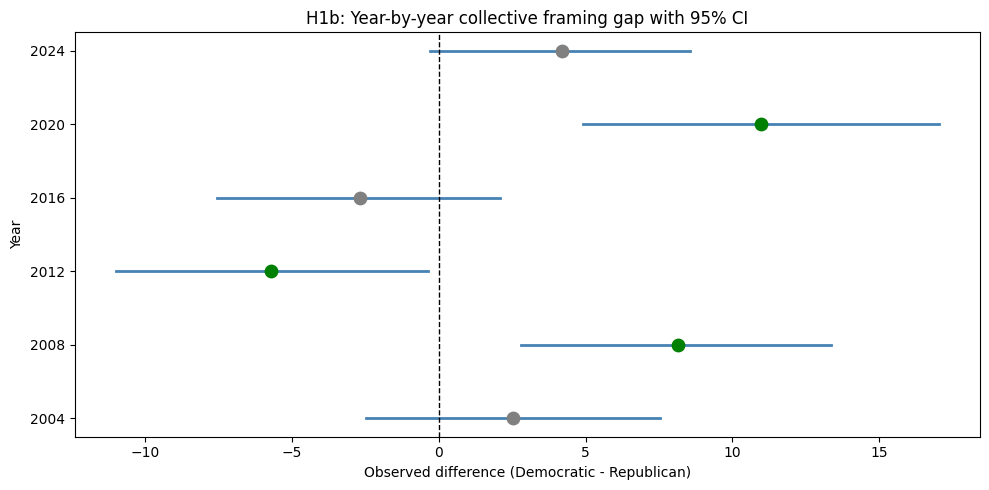

In [8]:
# Forest plot reads only from year_results (no hard-coded values)
years  = sorted(year_results)
diffs  = [year_results[y]["diff"]     for y in years]
lo     = [year_results[y]["ci_lower"] for y in years]
hi     = [year_results[y]["ci_upper"] for y in years]
colors = ["green" if year_results[y]["significant"] else "gray" for y in years]

fig, ax = plt.subplots(figsize=(10, 5))
for i, y in enumerate(years):
    ax.plot([lo[i], hi[i]], [i, i], color="steelblue", lw=2)
    ax.scatter(diffs[i], i, color=colors[i], zorder=5, s=80)
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years)
ax.set_xlabel("Observed difference (Democratic - Republican)")
ax.set_ylabel("Year")
ax.set_title("H1b: Year-by-year collective framing gap with 95% CI")
fig.tight_layout()
savefig(fig, "h1b_forest.png")
plt.show()

### Result - H1b

Significant years are green. Note the cycles where the sign flips (Republicans more collective than Democrats): these coincide with years in which the Democratic party held the presidency, foreshadowing the incumbency effect tested in H2 and H2b. The party-level effect and the incumbency effect interact - holding the White House pulls a party's convention toward "I" and away from "we", which compresses (and can reverse) the collective gap.

## Hypotheses 2 and 2b - Incumbency

**H2:** Incumbent-party speakers use "I" at a different rate than challengers (two-sided).
**H2b:** Incumbent and challenger speakers differ in "we" rate (two-sided).

2024 is genuinely ambiguous. The Democratic party held the White House, but President Biden withdrew and Vice President Harris became the nominee without being the sitting president; meanwhile the Republicans ran a former - not sitting - president. The **primary** analysis therefore excludes 2024 (`INCUMBENCY_2024 = "exclude"`). The sensitivity section re-runs H2 and H2b under all three codings (`exclude`, `dem_incumbent`, `rep_incumbent`).

Fixed incumbency coding for 2004-2020: 2004 Rep, 2008 Rep, 2012 Dem, 2016 Dem, 2020 Rep.

In [17]:
INCUMBENT_FIXED = {2004: "Republican", 2008: "Republican",
                   2012: "Democratic", 2016: "Democratic", 2020: "Republican"}

def incumbency_frame(data, mode):
    """Return a copy of `data` coded with is_incumbent for the chosen 2024
    handling. `mode` is one of exclude | dem_incumbent | rep_incumbent."""
    coding = dict(INCUMBENT_FIXED)
    if mode == "exclude":
        d = data[data["year"] != 2024].copy()
    elif mode == "dem_incumbent":
        d = data.copy(); coding[2024] = "Democratic"
    elif mode == "rep_incumbent":
        d = data.copy(); coding[2024] = "Republican"
    else:
        raise ValueError(f"unknown INCUMBENCY_2024: {mode!r}")
    d["is_incumbent"] = np.where(
        d["party"] == d["year"].map(coding), "Incumbent", "Challenger")
    return d

df_inc = incumbency_frame(df, INCUMBENCY_2024)
print(f"INCUMBENCY_2024 = {INCUMBENCY_2024!r}")
print("years included:", sorted(df_inc["year"].unique()))
print(df_inc["is_incumbent"].value_counts().to_string())

INCUMBENCY_2024 = 'exclude'
years included: [2004, 2008, 2012, 2016, 2020]
is_incumbent
Challenger    524
Incumbent     492


H2: 'I' rate, Incumbent vs Challenger  [exclude]
  group means:   +17.656  vs  +13.672   (n = 492, 524)
  observed diff: +3.984
  two-sided permutation p: 0.0000
  95% bootstrap CI: [+2.450, +5.520]
  -> reject H0 at alpha = 0.05
saved: h2_i_rate.png -> /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/figures/h2_i_rate.png | /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/paper/manuscript/figures/h2_i_rate.png


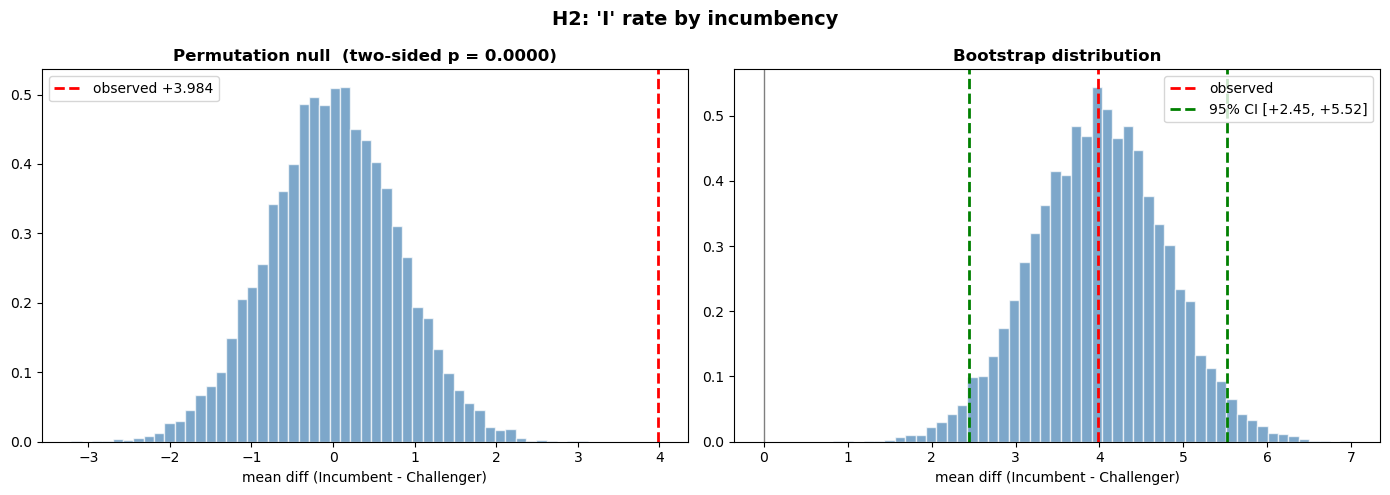

In [18]:
inc_i = df_inc.loc[df_inc["is_incumbent"] == "Incumbent",  "i_rate"]
cha_i = df_inc.loc[df_inc["is_incumbent"] == "Challenger", "i_rate"]

h2_perm = permutation_test(inc_i, cha_i)
h2_boot = bootstrap_ci(inc_i, cha_i)
summarize(f"H2: 'I' rate, Incumbent vs Challenger  [{INCUMBENCY_2024}]",
          h2_perm, h2_boot)
plot_test(h2_perm, h2_boot, "H2: 'I' rate by incumbency",
          "Incumbent", "Challenger", "h2_i_rate.png")

H2b: 'we' rate, Incumbent vs Challenger  [exclude]
  group means:   +16.244  vs  +18.932   (n = 492, 524)
  observed diff: -2.687
  two-sided permutation p: 0.0001
  95% bootstrap CI: [-4.022, -1.359]
  -> reject H0 at alpha = 0.05
saved: h2b_we_rate.png -> /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/figures/h2b_we_rate.png | /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/paper/manuscript/figures/h2b_we_rate.png


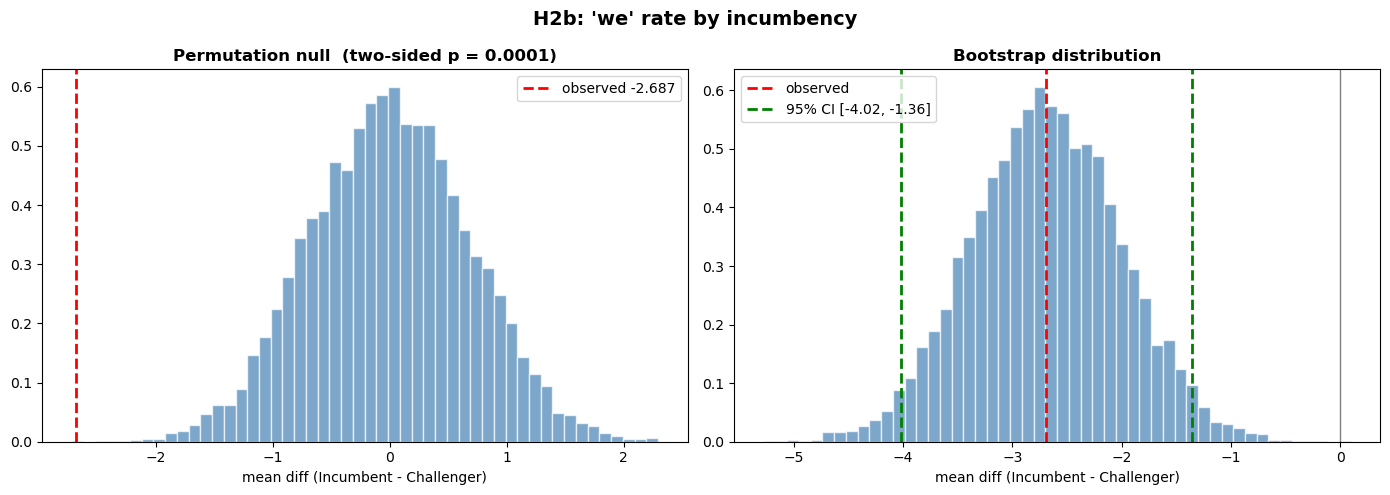

In [19]:
inc_we = df_inc.loc[df_inc["is_incumbent"] == "Incumbent",  "we_rate"]
cha_we = df_inc.loc[df_inc["is_incumbent"] == "Challenger", "we_rate"]

h2b_perm = permutation_test(inc_we, cha_we)
h2b_boot = bootstrap_ci(inc_we, cha_we)
summarize(f"H2b: 'we' rate, Incumbent vs Challenger  [{INCUMBENCY_2024}]",
          h2b_perm, h2b_boot)
plot_test(h2b_perm, h2b_boot, "H2b: 'we' rate by incumbency",
          "Incumbent", "Challenger", "h2b_we_rate.png")

### Result - H2 and H2b

Together these test the incumbency effect from both directions: incumbent-party speakers leaning to "I", challenger-party speakers to "we". Read significance from the printed summaries and CIs above. The active coding of 2024 is shown in each summary label; the sensitivity table below shows how robust the effect is to that choice.

## Speaker-role decomposition: nominees vs. surrogates

A post-hoc follow-up engaging Jarvis (2001), who found no incumbency effect on self-reference across nominee acceptance speeches. We re-run H2 and H2b separately for **nominees** (the presidential and VP nominees of each cycle) and **surrogates** (all other primetime speakers), with 2024 excluded as in the primary incumbency tests. Nominees are matched per cycle by exact name, so a figure who was a nominee in one cycle but a surrogate in another (e.g., Obama, keynote in 2004 then nominee in 2008/2012) is classified correctly for each speech. If the incumbency effect lives in the surrogate layer it should be strong among surrogates and wash out in the small nominee subset, reconciling the full-corpus result with Jarvis's nominee-only null.

In [20]:
# Presidential and VP nominees by cycle (2024 excluded for incumbency, as in H2/H2b).
NOMINEES = {
    (2004, "Democratic"): {"John Kerry", "John Edwards"},
    (2004, "Republican"): {"George W. Bush", "Dick Cheney"},
    (2008, "Democratic"): {"Barack Obama", "Joe Biden"},
    (2008, "Republican"): {"John McCain", "Sarah Palin"},
    (2012, "Democratic"): {"Barack Obama", "Joe Biden"},
    (2012, "Republican"): {"Mitt Romney", "Paul Ryan"},
    (2016, "Democratic"): {"Hillary Clinton", "Tim Kaine"},
    (2016, "Republican"): {"Donald Trump", "Mike Pence"},
    (2020, "Democratic"): {"Joe Biden", "Kamala Harris"},
    (2020, "Republican"): {"Donald Trump", "Mike Pence"},
}

# 2024-excluded, incumbency-coded frame; tag each speech as Nominee or Surrogate.
df_role = incumbency_frame(df, "exclude")
df_role["role"] = np.where(
    [spk in NOMINEES.get((yr, pty), set())
     for spk, yr, pty in zip(df_role["speaker"], df_role["year"], df_role["party"])],
    "Nominee", "Surrogate")

def incumbency_on(subset, rate_col):
    inc = subset.loc[subset["is_incumbent"] == "Incumbent",  rate_col]
    cha = subset.loc[subset["is_incumbent"] == "Challenger", rate_col]
    perm = permutation_test(inc, cha)
    boot = bootstrap_ci(inc, cha)
    return {"n": len(subset), "n_inc": len(inc), "n_cha": len(cha),
            "diff": perm["observed_diff"], "p": perm["p_value"],
            "ci_lower": boot["ci_lower"], "ci_upper": boot["ci_upper"]}

rows = []
for label, sub in [("Full corpus",     df_role),
                   ("Nominees only",   df_role[df_role["role"] == "Nominee"]),
                   ("Surrogates only", df_role[df_role["role"] == "Surrogate"])]:
    h2  = incumbency_on(sub, "i_rate")
    h2b = incumbency_on(sub, "we_rate")
    rows.append({"subset": label, "n": h2["n"],
                 "n_inc": h2["n_inc"], "n_cha": h2["n_cha"],
                 "H2_I_diff": h2["diff"],  "H2_p": h2["p"],
                 "H2b_We_diff": h2b["diff"], "H2b_p": h2b["p"]})

decomp = pd.DataFrame(rows)[["subset", "n", "n_inc", "n_cha",
                             "H2_I_diff", "H2_p", "H2b_We_diff", "H2b_p"]].round(4)
print("Incumbency effect by speaker role (2024 excluded, two-sided):")
print(decomp.to_string(index=False))
print()
print("Nominee speeches by cycle:")
print(df_role[df_role["role"] == "Nominee"]
      .groupby(["year", "party", "speaker"]).size().to_string())

Incumbency effect by speaker role (2024 excluded, two-sided):
         subset    n  n_inc  n_cha  H2_I_diff   H2_p  H2b_We_diff  H2b_p
    Full corpus 1016    492    524     3.9838 0.0000      -2.6874 0.0001
  Nominees only   21     10     11    -0.2726 0.9339      -3.5254 0.3458
Surrogates only  995    482    513     4.0742 0.0000      -2.6678 0.0000

Nominee speeches by cycle:
year  party       speaker        
2004  Democratic  John Edwards       1
                  John Kerry         1
      Republican  Dick Cheney        1
                  George W. Bush     1
2008  Democratic  Barack Obama       1
                  Joe Biden          2
      Republican  John McCain        1
                  Sarah Palin        1
2012  Democratic  Barack Obama       1
                  Joe Biden          1
      Republican  Mitt Romney        1
                  Paul Ryan          1
2016  Democratic  Hillary Clinton    1
                  Tim Kaine          1
      Republican  Donald Trump       1

## Sensitivity analyses

### 2024 incumbency coding - all three ways

H2 and H2b are re-run under each 2024 coding. The `exclude` row is the primary analysis; `dem_incumbent` and `rep_incumbent` bound the two alternative readings of 2024. A stable sign and significance across rows means the incumbency effect does not hinge on how 2024 is treated.

In [21]:
def run_incumbency(data, mode, rate_col):
    d = incumbency_frame(data, mode)
    inc = d.loc[d["is_incumbent"] == "Incumbent",  rate_col]
    cha = d.loc[d["is_incumbent"] == "Challenger", rate_col]
    perm = permutation_test(inc, cha)
    boot = bootstrap_ci(inc, cha)
    return {"hypothesis": None, "mode": mode,
            "years": d["year"].nunique(),
            "inc_mean": perm["g1_mean"], "cha_mean": perm["g2_mean"],
            "diff": perm["observed_diff"], "p_two_sided": perm["p_value"],
            "ci_lower": boot["ci_lower"], "ci_upper": boot["ci_upper"]}

rows = []
for hyp, rate in [("H2 (I rate)", "i_rate"), ("H2b (we rate)", "we_rate")]:
    for mode in ["exclude", "dem_incumbent", "rep_incumbent"]:
        r = run_incumbency(df, mode, rate)
        r["hypothesis"] = hyp
        r["primary"] = "*" if mode == "exclude" else ""
        rows.append(r)

sens = pd.DataFrame(rows)[["hypothesis", "mode", "primary", "years",
                           "inc_mean", "cha_mean", "diff",
                           "p_two_sided", "ci_lower", "ci_upper"]].round(4)
print("(* = primary analysis)")
print(sens.to_string(index=False))

(* = primary analysis)
   hypothesis          mode primary  years  inc_mean  cha_mean    diff  p_two_sided  ci_lower  ci_upper
  H2 (I rate)       exclude       *      5   17.6561   13.6723  3.9838       0.0000    2.4499    5.5197
  H2 (I rate) dem_incumbent              6   17.3927   14.8335  2.5592       0.0005    1.1447    3.9867
  H2 (I rate) rep_incumbent              6   18.0757   14.1794  3.8963       0.0000    2.4725    5.3381
H2b (we rate)       exclude       *      5   16.2445   18.9318 -2.6874       0.0001   -4.0218   -1.3594
H2b (we rate) dem_incumbent              6   16.5758   18.5806 -2.0048       0.0010   -3.1843   -0.8393
H2b (we rate) rep_incumbent              6   16.4159   18.7359 -2.3200       0.0003   -3.4801   -1.1755


### Word-cutoff sweep

H1, H2, and H2b recomputed across a range of minimum-length cutoffs (H2/H2b use the primary `exclude` coding). Stable estimates from no filter up to 500 words indicate the 215-word threshold is not load-bearing.

In [22]:
sweep = []
for cut in [0, 50, 100, 215, 500]:
    d = df_all[df_all["word_count"] >= cut].reset_index(drop=True)
    dem = d.loc[d["party"] == "Democratic", "collective_gap"]
    rep = d.loc[d["party"] == "Republican", "collective_gap"]
    h1 = permutation_test(dem, rep)
    di = incumbency_frame(d, "exclude")
    h2 = permutation_test(di.loc[di.is_incumbent == "Incumbent",  "i_rate"],
                          di.loc[di.is_incumbent == "Challenger", "i_rate"])
    h2b = permutation_test(di.loc[di.is_incumbent == "Incumbent",  "we_rate"],
                           di.loc[di.is_incumbent == "Challenger", "we_rate"])
    sweep.append({"cutoff": cut, "n": len(d),
                  "H1_diff": h1["observed_diff"],  "H1_p": h1["p_value"],
                  "H2_diff": h2["observed_diff"],  "H2_p": h2["p_value"],
                  "H2b_diff": h2b["observed_diff"], "H2b_p": h2b["p_value"]})
print(pd.DataFrame(sweep).round(4).to_string(index=False))

 cutoff    n  H1_diff   H1_p  H2_diff   H2_p  H2b_diff  H2b_p
      0 1800   1.4343 0.2560   2.5854 0.0033   -3.5524 0.0001
     50 1641   0.9254 0.4146   3.2498 0.0001   -2.5191 0.0001
    100 1515   1.3985 0.1928   2.7327 0.0003   -2.3547 0.0005
    215 1263   3.0347 0.0052   3.9838 0.0000   -2.6874 0.0001
    500  587   7.4313 0.0000   1.5056 0.0992   -2.6534 0.0029


### Challenger - incumbent collective gap, by year

Descriptive view of the incumbency effect over time, under the active `INCUMBENCY_2024` setting (so 2024 appears only when it is coded rather than excluded).

saved: incumbency_gap_by_year.png -> /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/figures/incumbency_gap_by_year.png | /Users/chandler/Library/CloudStorage/Dropbox/research/convention-speeches/paper/manuscript/figures/incumbency_gap_by_year.png


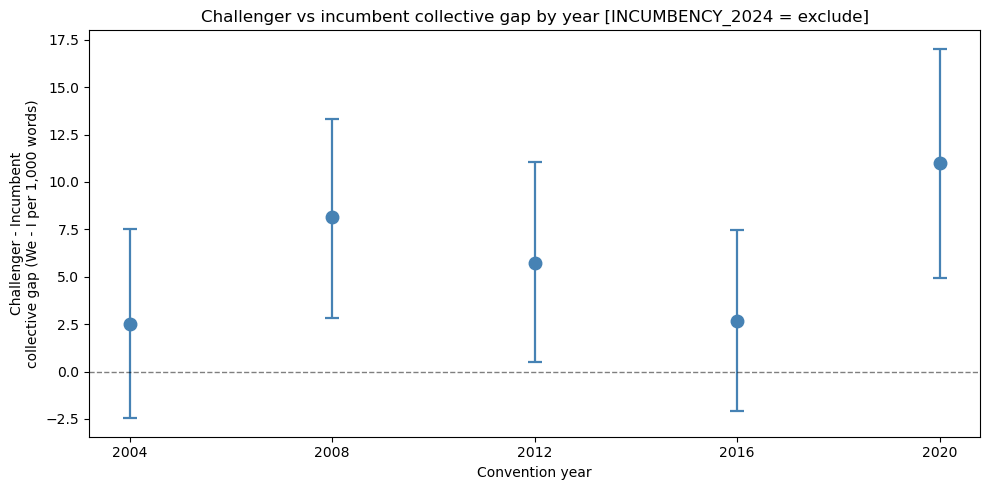

In [23]:
dfi = incumbency_frame(df, INCUMBENCY_2024)
rows = []
for y in sorted(dfi["year"].unique()):
    yd  = dfi[dfi["year"] == y]
    cha = yd.loc[yd["is_incumbent"] == "Challenger", "collective_gap"]
    inc = yd.loc[yd["is_incumbent"] == "Incumbent",  "collective_gap"]
    boot = bootstrap_ci(cha, inc)
    rows.append((y, boot["observed_diff"], boot["ci_lower"], boot["ci_upper"]))

fig, ax = plt.subplots(figsize=(10, 5))
for y, d, l, h in rows:
    ax.errorbar(y, d, yerr=[[d - l], [h - d]], fmt="o", color="steelblue",
                markersize=9, capsize=5, capthick=1.6, lw=1.6)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Convention year")
ax.set_ylabel("Challenger - Incumbent\ncollective gap (We - I per 1,000 words)")
ax.set_title(f"Challenger vs incumbent collective gap by year "
             f"[INCUMBENCY_2024 = {INCUMBENCY_2024}]")
ax.set_xticks([r[0] for r in rows])
fig.tight_layout()
savefig(fig, "incumbency_gap_by_year.png")
plt.show()

## Notes

- All p-values are two-sided permutation tests (10,000 shuffles, seed 42);
  CIs are 95% bootstrap (10,000 resamples).
- The unit of analysis is the speech; a speaker with multiple speeches
  contributes multiple rows.
- To reproduce: `make pronouns` regenerates `../data/pronoun_counts.csv`, then
  run this notebook top to bottom. Figures are written to `figures/` and, if
  the working repo is checked out alongside, mirrored to its manuscript
  figures folder.